# Verification measure 2, synthese pour le rapport

Ce notebook regroupe les sorties deja calculees dans `outputs/verification_measure_2`.
Le but est de voir comment resumer proprement plusieurs essais dans le rapport, sans empiler six fois les memes graphes.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if Path("outputs").exists():
    PROJECT_ROOT = Path(".")
elif Path("../outputs").exists():
    PROJECT_ROOT = Path("..")
else:
    raise FileNotFoundError("Impossible de localiser le dossier outputs depuis ce notebook.")

BASE = PROJECT_ROOT / "outputs" / "verification_measure_2"
SUMMARY_PATH = BASE / "verification_measure_2_summary.csv"

summary = pd.read_csv(SUMMARY_PATH)
summary["cycle"] = summary["cycle"].astype(str)
summary = summary.sort_values("cycle", key=lambda s: s.astype(int)).reset_index(drop=True)

aligned_by_cycle = {}
for cycle in summary["cycle"]:
    p = BASE / cycle / "verification_aligned.csv"
    df = pd.read_csv(p, parse_dates=["btn_dt", "pred_dt_first", "pred_dt_last"])
    df["cycle"] = cycle
    aligned_by_cycle[cycle] = df

summary

,cycle,button_file,prediction_file,n_pairs,rmse,mae,mape_pct,r2,corr_pearson,bias_mean,residual_mean,residual_std,button_period_s,half_window_s,mean_pred_points_per_button
0,1,1_button_test_01ul.xls,1_measure_20260526_135044_HA.txt,283.0,0.911710,0.781127,5.784454,0.680018,0.909159,-0.606122,0.606122,0.682259,2.0,1.0,34.091873
1,2,2_button_test_02ul.xls,2_measure_20260526_141011_HA.txt,287.0,0.830130,0.735779,4.740436,0.878944,0.970984,-0.544873,0.544873,0.627376,2.0,1.0,33.505226
2,4,4_button_test_02ul.xls,4_measure_20260526_144610_HA.txt,759.0,1.794198,1.602040,9.494602,0.560106,0.959897,-1.581037,1.581037,0.848774,1.0,0.5,15.515152
3,5,5_button_test_02ul.xls,5_measure_20260526_153158_HA.txt,354.0,1.573284,1.472316,9.957257,0.712392,0.981630,-1.470144,1.470144,0.561060,2.0,1.0,40.754237
4,6,6_button_test_02ul.xls,6_measure_20260526_155101_HA.txt,143.0,0.938258,0.859565,6.189934,0.878586,0.948809,-0.323343,0.323343,0.883878,2.0,1.0,37.013986
5,7,7_button_test_02ul.xls,7_measure_20260526_160458_HA.txt,228.0,1.171269,1.055425,7.166979,0.812430,0.970731,-0.966362,0.966362,0.663283,2.0,1.0,38.657895


## 1. Tableau recapitulatif des essais

Ce tableau permet deja de voir quels essais sont les plus propres.
Pour le rapport, on peut en reprendre une version compacte.


In [2]:
cols = ['cycle', 'n_pairs', 'corr_pearson', 'r2', 'rmse', 'mae', 'mape_pct', 'bias_mean']
summary[cols].round({'corr_pearson': 3, 'r2': 3, 'rmse': 3, 'mae': 3, 'mape_pct': 2, 'bias_mean': 3})


,cycle,n_pairs,corr_pearson,r2,rmse,mae,mape_pct,bias_mean
0,1,283.0,0.909,0.680,0.912,0.781,5.78,-0.606
1,2,287.0,0.971,0.879,0.830,0.736,4.74,-0.545
2,4,759.0,0.960,0.560,1.794,1.602,9.49,-1.581
3,5,354.0,0.982,0.712,1.573,1.472,9.96,-1.470
4,6,143.0,0.949,0.879,0.938,0.860,6.19,-0.323
5,7,228.0,0.971,0.812,1.171,1.055,7.17,-0.966


## 2. Metriques par essai

Ces graphes permettent de voir rapidement si un essai sort du lot.


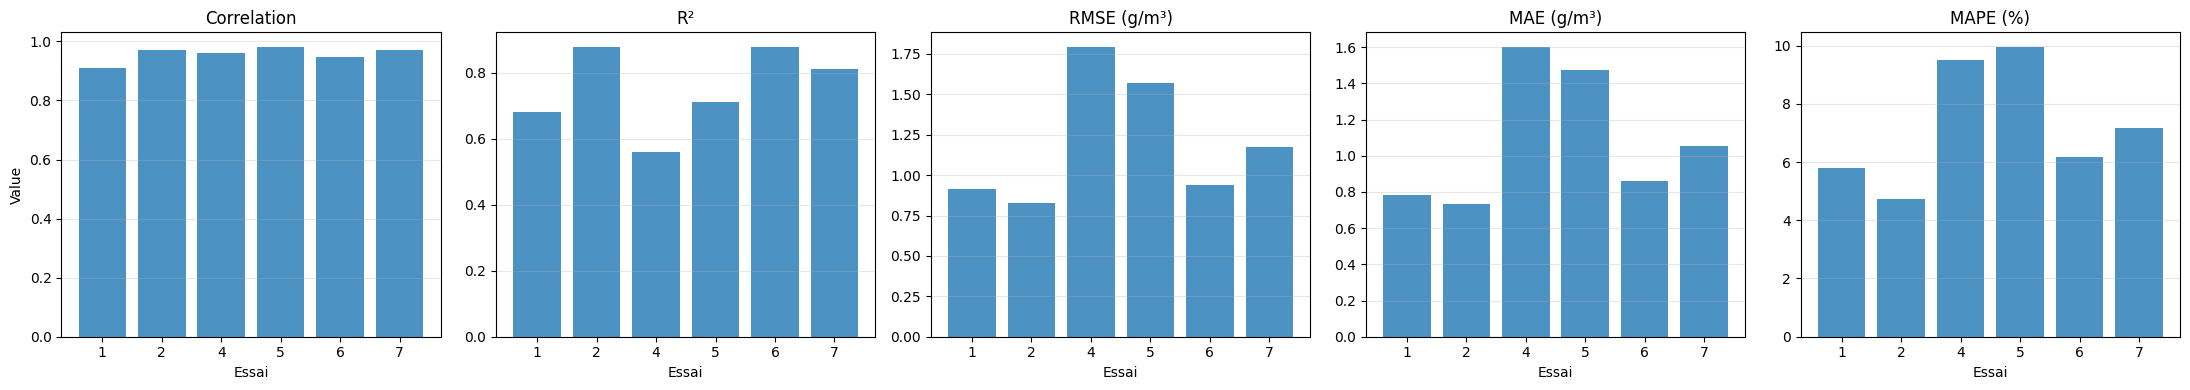

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
metrics_to_plot = [
    ('corr_pearson', 'Correlation'),
    ('r2', 'R²'),
    ('rmse', 'RMSE (g/m³)'),
    ('mae', 'MAE (g/m³)'),
    ('mape_pct', 'MAPE (%)'),
]

for ax, (col, title) in zip(axes, metrics_to_plot):
    ax.bar(summary['cycle'], summary[col], color='tab:blue', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Essai')
    ax.grid(True, axis='y', alpha=0.3)

axes[0].set_ylabel('Value')
plt.tight_layout()
plt.show()


## 3. Scatter global

Chaque couleur correspond a un essai.
Ce graphe est un bon candidat pour le rapport si on veut resumer plusieurs essais sur une seule figure.


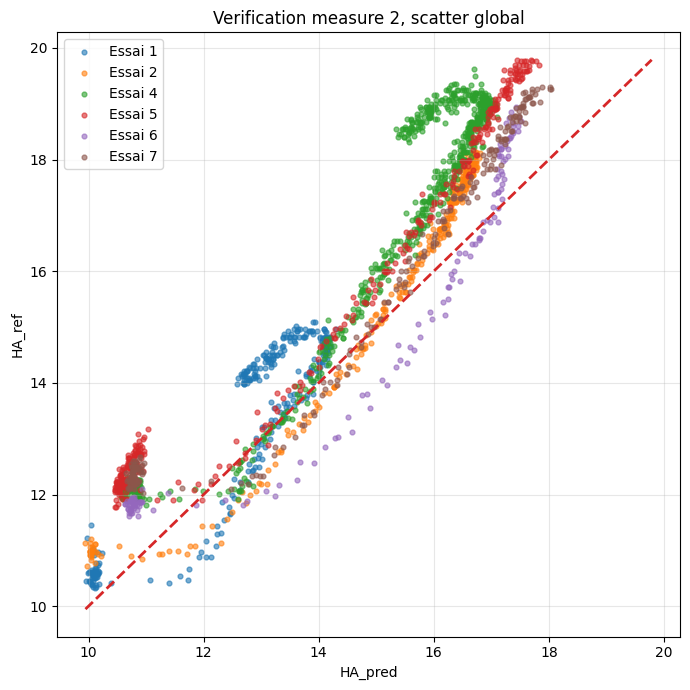

In [4]:
all_aligned = pd.concat(aligned_by_cycle.values(), ignore_index=True)

fig, ax = plt.subplots(figsize=(7, 7))
for cycle, df in aligned_by_cycle.items():
    ax.scatter(df['HA_pred'], df['HA_ref'], s=12, alpha=0.6, label=f'Essai {cycle}')

lo = float(min(all_aligned['HA_pred'].min(), all_aligned['HA_ref'].min()))
hi = float(max(all_aligned['HA_pred'].max(), all_aligned['HA_ref'].max()))
ax.plot([lo, hi], [lo, hi], color='tab:red', linestyle='--', linewidth=2)
ax.set_xlabel('HA_pred')
ax.set_ylabel('HA_ref')
ax.set_title('Verification measure 2, scatter global')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 4. Residuals globaux

Ce graphe montre si certains essais presentent un biais plus marque que les autres.


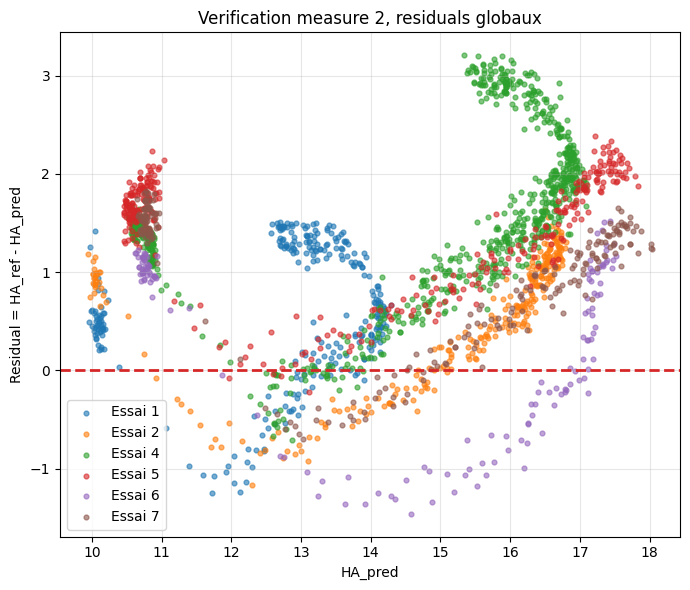

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
for cycle, df in aligned_by_cycle.items():
    ax.scatter(df['HA_pred'], df['residual'], s=12, alpha=0.6, label=f'Essai {cycle}')

ax.axhline(0.0, color='tab:red', linestyle='--', linewidth=2)
ax.set_xlabel('HA_pred')
ax.set_ylabel('Residual = HA_ref - HA_pred')
ax.set_title('Verification measure 2, residuals globaux')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 5. Time series representatives

Superposer tous les essais sur une seule figure n'est pas lisible.
On prend donc trois cas representatives, le meilleur, le median, et le moins bon selon la RMSE.


In [6]:
ordered = summary.sort_values('rmse').reset_index(drop=True)
selected_cycles = [ordered.iloc[0]['cycle'], ordered.iloc[len(ordered)//2]['cycle'], ordered.iloc[-1]['cycle']]
selected_cycles = list(dict.fromkeys(selected_cycles))
selected_cycles


['2', '7', '4']

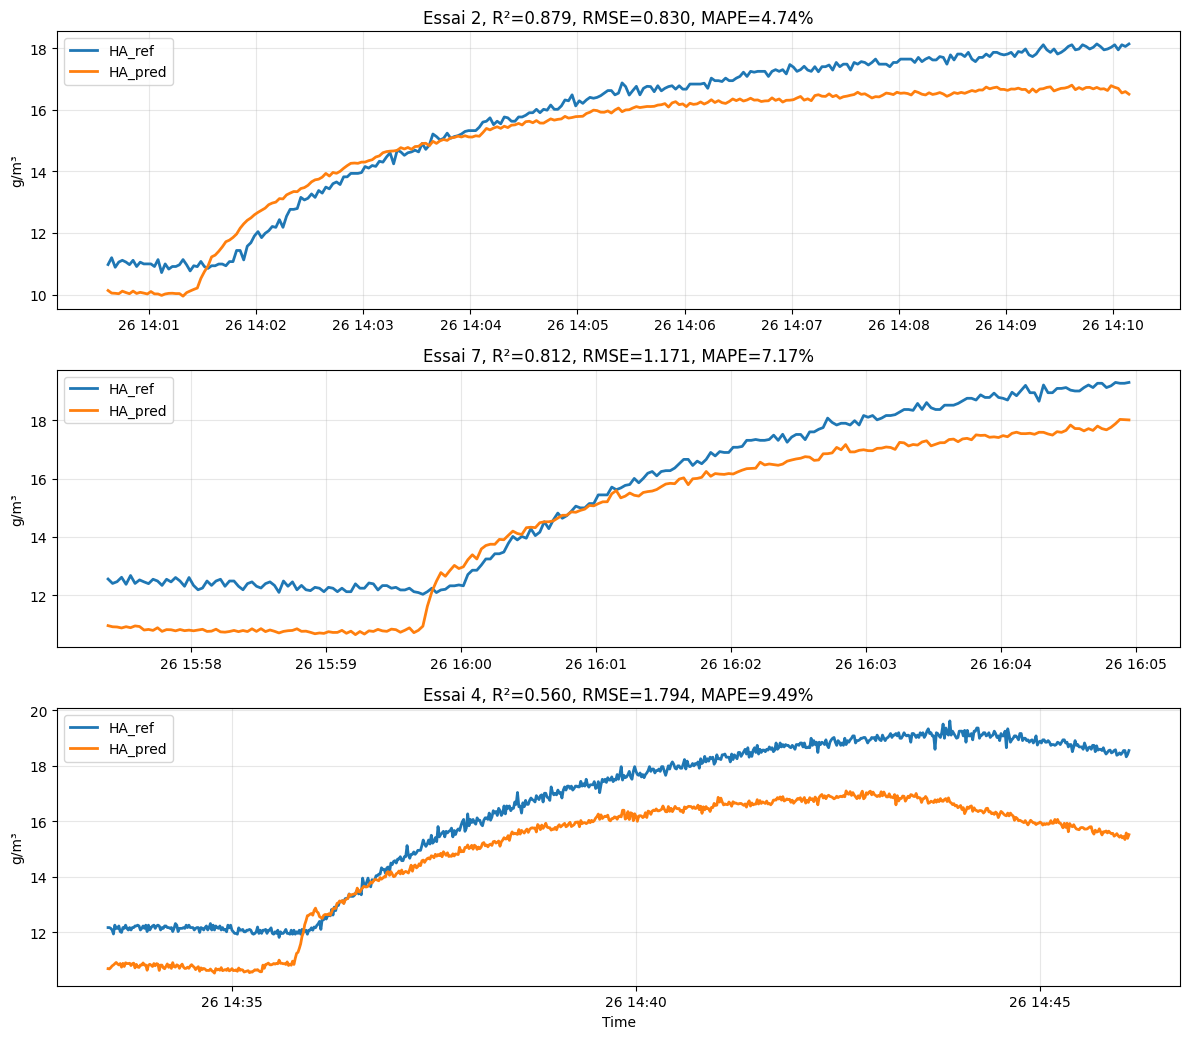

In [7]:
fig, axes = plt.subplots(len(selected_cycles), 1, figsize=(12, 3.5 * len(selected_cycles)), sharex=False)
if len(selected_cycles) == 1:
    axes = [axes]

for ax, cycle in zip(axes, selected_cycles):
    df = aligned_by_cycle[cycle].sort_values('btn_dt')
    row = summary.loc[summary['cycle'] == cycle].iloc[0]
    ax.plot(df['btn_dt'], df['HA_ref'], label='HA_ref', linewidth=2)
    ax.plot(df['btn_dt'], df['HA_pred'], label='HA_pred', linewidth=2)
    ax.set_title(f'Essai {cycle}, R²={row.r2:.3f}, RMSE={row.rmse:.3f}, MAPE={row.mape_pct:.2f}%')
    ax.set_ylabel('g/m³')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()


## 6. Piste pour le rapport

Option sobre :

- garder P2 comme verification principale, avec les trois graphes deja produits
- ajouter une sous-partie courte sur la repetabilite, avec le tableau recapitulatif des essais et le scatter global
- si besoin, ajouter une figure de time series representative, pas les six
